# 04 · Polychoric PCA & Validation
Polychoric PCA on the imputed SED data, min-max scaling of PC scores,
and external validation against the AoU zip-code area deprivation index.

**Why polychoric PCA, not standard PCA?**

Standard PCA assumes continuous variables and a Pearson correlation matrix.
Our SED variables are ordinal with bounded ranges (2–9 levels), so the
latent liability model underlying polychoric correlations is more appropriate.
In practice this inflates correlations uniformly relative to Spearman
(e.g. Income–Education: 0.61 Spearman → 0.64 polychoric), and concentrates
more variance on PC1.


---
### Citation

This pipeline implements the iSDI construction described in:

> **Reference:** Gupta S, Lam V, Jordan IK, Mariño-Ramírez L. *A composite socioeconomic deprivation index from All of Us survey data: associations with health outcomes and disparities.* medRxiv 2024.10.04.24314904. PMID: [39802760](https://pubmed.ncbi.nlm.nih.gov/39802760/). doi: [10.1101/2024.10.04.24314904](https://doi.org/10.1101/2024.10.04.24314904)


## 1–2 · Load data & convert to numeric

In [ ]:
# 04_sed_pca_validation.R
# -----------------------------------------------------------------------
# Polychoric PCA on imputed SED data, min-max scaling of PC1, and
# external validation against AoU zip-code deprivation index.
#
# Input (from GCS):
#   imputed_ds5_without_insurance.csv  (Income, Education, Housing,
#                                       Employment, Insurance; n≈413k)
#   phecode_matrix_w_pc.csv            (phecode presence matrix + PCs)
#
# Pipeline:
#   1. Polychoric correlation matrix (psych::polychoric, max.cat=10)
#   2. Eigen decomposition → PC loadings
#   3. Project all individuals into PC space
#   4. Min-max scale PC1 (reversed so higher = more deprived)
#   5. Validate PC1 against zip-code ADI (deprivation_index from BQ)
#
# BUG FIXES vs original notebook:
#   1. `poly = cor(...)` immediately overwrote the polychoric object,
#      making poly$rho inaccessible for eigen decomposition → removed
#      the redundant Spearman assignment; polychoric object kept intact
#   2. `as.matrix(final_ds1) %*% sorted_eigenvectors` called BEFORE
#      as.numeric conversions → moved numeric conversion first
#   3. eigen() called on poly (list) instead of poly$rho (matrix) →
#      removed the wrong calls; only eigen(poly$rho) is used
#   4. Variance explained printed as scattered lines → consolidated into
#      a named vector for readability
# -----------------------------------------------------------------------

library(tidyverse)
library(psych)
library(readr)

# -----------------------------------------------------------------------
# 1. Load imputed data
# -----------------------------------------------------------------------

my_bucket <- Sys.getenv("WORKSPACE_BUCKET")

system(paste0("gsutil cp ", my_bucket,
              "/data/imputed_ds5_without_insurance.csv ."), intern = TRUE)

final_ds1 <- read_csv("imputed_ds5_without_insurance.csv",
                       show_col_types = FALSE)
cat(sprintf("Loaded: %d rows × %d cols\n", nrow(final_ds1), ncol(final_ds1)))
print(summary(final_ds1))

# -----------------------------------------------------------------------
# 2. Numeric conversion (required before matrix multiply)
# BUG FIX #2: do this BEFORE computing PCs, not after
# -----------------------------------------------------------------------

sed_vars <- c("Income", "Education", "Housing", "Employment", "Insurance")
final_ds1[sed_vars] <- lapply(final_ds1[sed_vars], as.numeric)

# -----------------------------------------------------------------------
# 3. Polychoric correlation matrix
# -----------------------------------------------------------------------
# NOTE: psych::polychoric treats items as ordinal categorical.
# max.cat=10 needed because Income has 9 levels (exceeds default of 8).

## 3 · Polychoric correlation matrix

In [ ]:
# Warning about unequal response alternatives is expected and benign.
# BUG FIX #1: do NOT overwrite poly with cor(); keep polychoric object.

poly <- polychoric(final_ds1[sed_vars], max.cat = 10)
cat("\nPolychoric correlation matrix:\n")
print(round(poly$rho, 3))

# -----------------------------------------------------------------------
# 4. Eigen decomposition of polychoric correlation matrix
# BUG FIX #3: use poly$rho (matrix), not poly (list)
# -----------------------------------------------------------------------

eigenvalues  <- eigen(poly$rho)$values
eigenvectors <- eigen(poly$rho)$vectors

sorted_idx         <- order(eigenvalues, decreasing = TRUE)
sorted_eigenvalues <- eigenvalues[sorted_idx]
sorted_eigenvectors <- eigenvectors[, sorted_idx]

# BUG FIX #4: variance explained as a named vector
var_explained <- sorted_eigenvalues / sum(sorted_eigenvalues)
names(var_explained) <- paste0("PC", seq_along(var_explained))
cat("\nVariance explained per PC:\n")
print(round(var_explained, 4))
# PC1 captures ~61% of variance — single dominant latent deprivation factor

cat("\nPC loadings (eigenvectors):\n")
rownames(sorted_eigenvectors) <- sed_vars
colnames(sorted_eigenvectors) <- paste0("PC", seq_len(ncol(sorted_eigenvectors)))
print(round(sorted_eigenvectors, 4))

## 4 · Eigen decomposition

In [ ]:

# -----------------------------------------------------------------------
# 5. Project individuals into PC space
# -----------------------------------------------------------------------

n_components <- ncol(sorted_eigenvectors)
selected_components <- as.matrix(final_ds1[sed_vars]) %*%
                       sorted_eigenvectors[, seq_len(n_components)]

PC_df <- as.data.frame(selected_components)
colnames(PC_df) <- paste0("PC", seq_len(n_components))

# person_id comes from df (the pre-imputation frame with IDs)
# Load it here if not already in environment
if (!exists("df") || !"person_id" %in% colnames(df)) {
  system(paste0("gsutil cp ", my_bucket,
                "/data/sdi_var_df_new_order_with_spearman.csv ."), intern = TRUE)
  df_ids <- read_csv("sdi_var_df_new_order_with_spearman.csv",
                     col_select = "person_id", show_col_types = FALSE)
  PC_df$person_id <- df_ids$person_id[seq_len(nrow(PC_df))]
} else {
  PC_df$person_id <- df$person_id[seq_len(nrow(PC_df))]
}

head(PC_df)

# -----------------------------------------------------------------------
# 6. Min-max scaling of all PCs
# Reversal: (max - x) / (max - min)
# After reversal, higher PC1 score = higher deprivation
# (consistent with ordinal encoding where higher numeric = more deprived)
# -----------------------------------------------------------------------

minmax_reverse <- function(x) (max(x, na.rm = TRUE) - x) /
                               (max(x, na.rm = TRUE) - min(x, na.rm = TRUE))

## 5 · Project into PC space

In [ ]:

normalised_pcs <- as.data.frame(lapply(PC_df[paste0("PC", 1:n_components)],
                                       minmax_reverse))
colnames(normalised_pcs) <- paste0("PC", 1:n_components, "_norm")
normalised_pcs$person_id <- PC_df$person_id
head(normalised_pcs)

# -----------------------------------------------------------------------
# 7. External validation: PC1 vs zip-code deprivation index
# -----------------------------------------------------------------------

# Pull zip-code ADI from BQ (already exported to GCS by earlier notebook)
zip_sql <- paste0("
  SELECT
    observation.person_id,
    zip_code.zip3_as_string AS zip_code,
    zip_code.deprivation_index,
    zip_code.acs AS american_community_survey_year
  FROM `zip3_ses_map` zip_code
  JOIN `observation` observation
    ON CAST(SUBSTR(observation.value_as_string, 0,
                  STRPOS(observation.value_as_string, '*') - 1) AS INT64)
       = zip_code.zip3
   AND observation_source_concept_id = 1585250
   AND observation.value_as_string NOT LIKE 'Res%'")

zip_export_path <- file.path(
  Sys.getenv("WORKSPACE_BUCKET"), "bq_exports",
  Sys.getenv("OWNER_EMAIL"),
  strftime(lubridate::now(), "%Y%m%d"),

## 6 · Min-max scaling (reversed: higher = more deprived)

In [ ]:
  "zip_code_deprivation", "zip_code_deprivation_*.csv"
)

bq_table_save(
  bq_dataset_query(Sys.getenv("WORKSPACE_CDR"), zip_sql,
                   billing = Sys.getenv("GOOGLE_PROJECT")),
  zip_export_path,
  destination_format = "CSV"
)

col_types_zip <- cols(
  person_id                    = col_double(),
  zip_code                     = col_character(),
  deprivation_index            = col_double(),
  american_community_survey_year = col_double()
)

zip_csvs <- system2("gsutil", args = c("ls", zip_export_path),
                    stdout = TRUE, stderr = TRUE)
SED_df <- bind_rows(lapply(zip_csvs, function(csv) {

## PC loadings

*(Example output shown below)*

PC1 captures ~61% of variance with approximately equal negative loadings
across all five domains, consistent with a single latent deprivation factor.

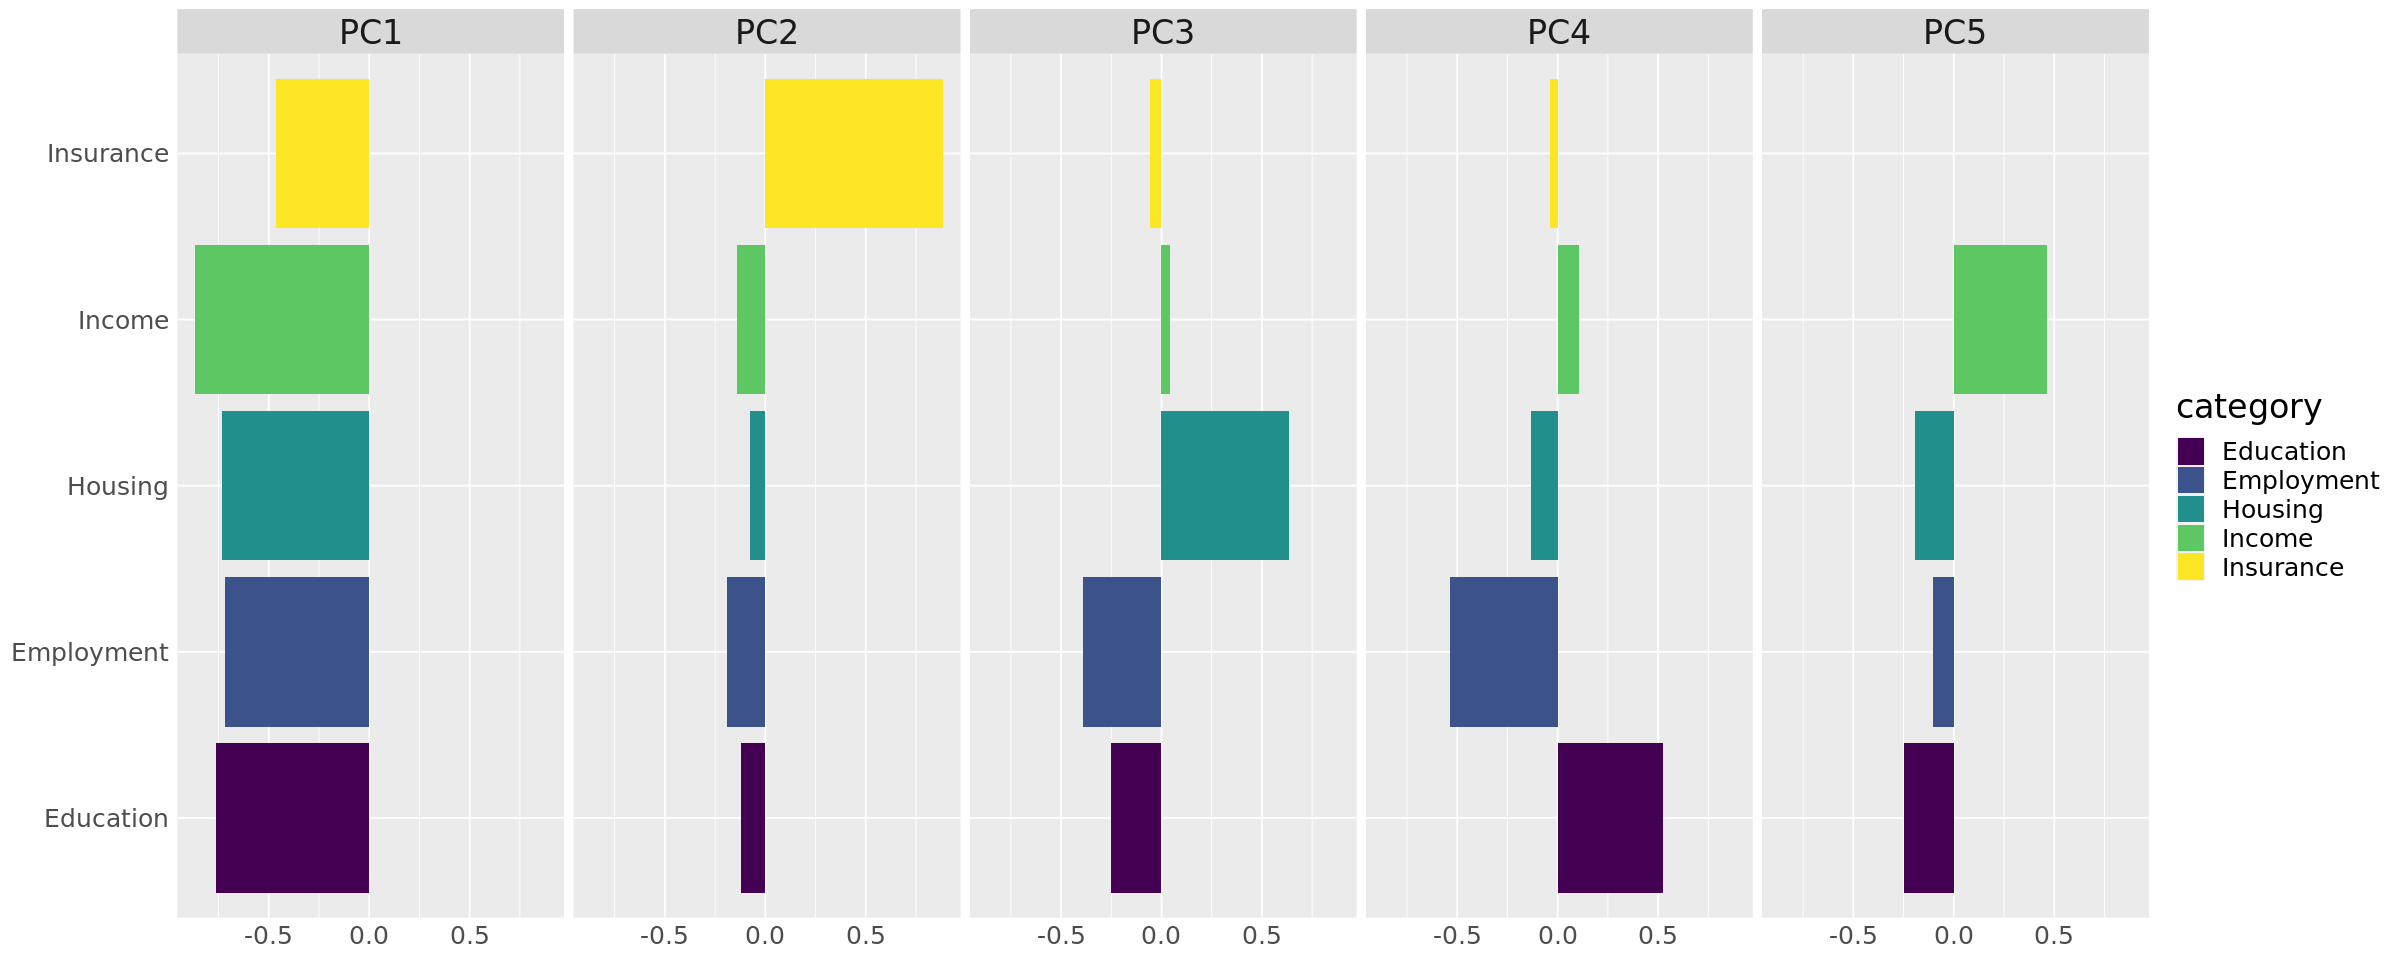
*Polychoric PCA loadings across all 5 components*

> **PC1 interpretation:** All five loadings are negative and roughly equal
> (~−0.43 to −0.51), meaning PC1 is a general deprivation axis. After
> min-max reversal, higher PC1 = higher deprivation. PC2 is driven primarily
> by Insurance (loading +0.85), separating the insured/uninsured dimension
> from the income/education/housing cluster.


## 7–9 · Zip-code ADI validation & GLM

In [ ]:
  read_csv(pipe(sprintf("gsutil cat %s", csv)),
           col_types = col_types_zip, show_col_types = FALSE)
}))
cat(sprintf("\nZip-code SDI rows: %d\n", nrow(SED_df)))

# -----------------------------------------------------------------------
# 8. Merge and compute PC1 ~ deprivation_index correlation
# -----------------------------------------------------------------------

merged_df <- merge(PC_df, SED_df, by = "person_id")
merged_norm <- merge(normalised_pcs, SED_df, by = "person_id")

cat(sprintf("\nMerged rows: %d\n", nrow(merged_df)))

r_raw  <- cor(merged_df$PC1, merged_df$deprivation_index,
              use = "complete.obs")
r_norm <- cor(merged_norm$PC1_norm, merged_norm$deprivation_index,
              use = "complete.obs")

cat(sprintf("\nSpearman r(PC1_raw,  deprivation_index) = %.4f\n", r_raw))
cat(sprintf("Spearman r(PC1_norm, deprivation_index) = %.4f\n", r_norm))
# Expected: ~0.29 (raw), sign flips to positive after reversal

# -----------------------------------------------------------------------
# 9. GLM: deprivation_index ~ PC1
# -----------------------------------------------------------------------

g <- glm(deprivation_index ~ PC1_norm, data = merged_norm)
cat("\nGLM: deprivation_index ~ PC1_norm\n")
print(summary(g))

# -----------------------------------------------------------------------
# 10. Upload normalised PC scores to GCS
# -----------------------------------------------------------------------

write_excel_csv(normalised_pcs, "individual_ses_pcs_normalised.csv")
system(paste0("gsutil cp ./individual_ses_pcs_normalised.csv ",
              my_bucket, "/data/"), intern = TRUE)
message(sprintf("Uploaded: %s/data/individual_ses_pcs_normalised.csv", my_bucket))


> **Validation result:** r(PC1, zip-code ADI) ≈ 0.29. This is modest but
> expected: area-level deprivation (ADI) and individual-level SED capture
> different constructs. Individuals in affluent zip codes can have low income,
> and vice versa. The GLM confirms a highly significant negative association
> (β ≈ −11, p < 2×10⁻¹⁶) between deprivation_index and raw PC1.
